<a href="https://colab.research.google.com/github/josemesa0112/machine-learning-repository/blob/main/Machine_Learning_applied_to_Crime_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INSTALACIÓN Y CARGA DEL DATASET**

In [1]:
!pip install ucimlrepo -q

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
communities = fetch_ucirepo(id=183)

X = communities.data.features
y = communities.data.targets

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Variable objetivo:", y.columns.tolist())

Dimensión de X: (1994, 127)
Dimensión de y: (1994, 1)
Variable objetivo: ['ViolentCrimesPerPop']


## **UNIFICAR DATOS**

In [5]:
df = pd.concat([X, y], axis=1)

print("Dimensión completa del dataset:", df.shape)
df.head()

Dimensión completa del dataset: (1994, 128)


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


## **REVISIÓN DE ESTRUCTURA GENERAL**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(100), int64(2), object(26)
memory usage: 1.9+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
state,1994.0,28.683551,16.397553,1.0,12.00,34.00,42.00,56.0
fold,1994.0,5.493982,2.873694,1.0,3.00,5.00,8.00,10.0
population,1994.0,0.057593,0.126906,0.0,0.01,0.02,0.05,1.0
householdsize,1994.0,0.463395,0.163717,0.0,0.35,0.44,0.54,1.0
racepctblack,1994.0,0.179629,0.253442,0.0,0.02,0.06,0.23,1.0
...,...,...,...,...,...,...,...,...
LandArea,1994.0,0.065231,0.109459,0.0,0.02,0.04,0.07,1.0
PopDens,1994.0,0.232854,0.203092,0.0,0.10,0.17,0.28,1.0
PctUsePubTrans,1994.0,0.161685,0.229055,0.0,0.02,0.07,0.19,1.0
LemasPctOfficDrugUn,1994.0,0.094052,0.240328,0.0,0.00,0.00,0.00,1.0


## **DEFINIR VARIABLE OBJETIVO**

In [8]:
target_col = "ViolentCrimesPerPop"

print("Variable objetivo:", target_col)
print(df[target_col].describe())

Variable objetivo: ViolentCrimesPerPop
count    1994.000000
mean        0.237979
std         0.232985
min         0.000000
25%         0.070000
50%         0.150000
75%         0.330000
max         1.000000
Name: ViolentCrimesPerPop, dtype: float64


## **ELIMINAR COLUMNAS IDENTIFICADORAS**

Estas columnas no aportan información relevante para la predicción ya que solo son identificadores.

In [9]:
cols_to_drop = []

for col in ["state", "county", "community", "communityname", "fold"]:
    if col in df.columns:
        cols_to_drop.append(col)

print("Columnas eliminadas:", cols_to_drop)

df_model = df.drop(columns=cols_to_drop)

print("Dimensión después de eliminar identificadores:", df_model.shape)

Columnas eliminadas: ['state', 'county', 'community', 'communityname', 'fold']
Dimensión después de eliminar identificadores: (1994, 123)


In [20]:
#print(df_model.dtypes[df_model.dtypes != "float64"])
print(" ")
print(df_model.isna().sum()[df_model.isna().sum() == 0])

 
population             0
householdsize          0
racepctblack           0
racePctWhite           0
racePctAsian           0
                      ..
LemasPctPolicOnPatr    0
LemasGangUnitDeploy    0
LemasPctOfficDrugUn    0
PolicBudgPerPop        0
ViolentCrimesPerPop    0
Length: 123, dtype: int64


## **CONVERTIR VARIABLES A NUMÉRICAS**

In [23]:
df_model= df_model.apply(pd.to_numeric, errors="coerce")

print(df_model.dtypes.value_counts())

float64    123
Name: count, dtype: int64


## **REVISAR DATOS FALTANTES**

In [24]:
missing_values = df_model.isnull().sum()
missing_percent = (missing_values / len(df_model)) * 100

missing_table = pd.DataFrame({
    "missing_values": missing_values,
    "missing_percent": missing_percent
}).sort_values(by="missing_percent", ascending=False)

missing_table[missing_table["missing_values"] > 0].head(30)

,missing_values,missing_percent
PolicAveOTWorked,1675,84.002006
LemasTotalReq,1675,84.002006
LemasSwFTFieldPerPop,1675,84.002006
PctPolicWhite,1675,84.002006
RacialMatchCommPol,1675,84.002006
LemasSwFTPerPop,1675,84.002006
LemasSwFTFieldOps,1675,84.002006
PolicReqPerOffic,1675,84.002006
LemasTotReqPerPop,1675,84.002006
LemasSwornFT,1675,84.002006


## **IMPUTACIÓN DE DATOS FALTANTES**

In [33]:
svmImputer = SVR(kernel='rbf')

svmImputer = IterativeImputer(estimator = svmImputer, max_iter=10, random_state=42)

df_model_imputed = pd.DataFrame(svmImputer.fit_transform(df_model), columns=df_model.columns)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [41]:
df_model_imputed.isna().sum()[df_model_imputed.isna().sum() != 0] #verificando los datos faltantes luego de la imputación

,0


## **ELIMINAR COLUMNAS CON MUCHOS DATOS FALTANTES**

Columnas con más del 40% de valores faltantes.

In [42]:
threshold_missing = 40

cols_high_missing = missing_table[
    missing_table["missing_percent"] > threshold_missing
].index.tolist()

# Nunca eliminar la variable objetivo
if target_col in cols_high_missing:
    cols_high_missing.remove(target_col)

print("Columnas con más del 40% de datos faltantes:")
print(cols_high_missing)

df_model = df_model.drop(columns=cols_high_missing)

print("Dimensión después de eliminar columnas con muchos faltantes:", df_model.shape)

Columnas con más del 40% de datos faltantes:
['PolicAveOTWorked', 'LemasTotalReq', 'LemasSwFTFieldPerPop', 'PctPolicWhite', 'RacialMatchCommPol', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'PolicReqPerOffic', 'LemasTotReqPerPop', 'LemasSwornFT', 'PolicPerPop', 'PolicBudgPerPop', 'LemasGangUnitDeploy', 'LemasPctPolicOnPatr', 'PolicCars', 'PolicOperBudg', 'PctPolicMinor', 'PctPolicAsian', 'PctPolicHisp', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz', 'PctPolicBlack']
Dimensión después de eliminar columnas con muchos faltantes: (1994, 101)


Para la variable 'OtherPerCap' como solo tiene un dato faltante, le imputamos la media

In [55]:
df_model['OtherPerCap'][df_model['OtherPerCap'].isna() != 0] = df_model['OtherPerCap'].mean()

/tmp/ipykernel_538/720923645.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_model['OtherPerCap'][df_model['OtherPerCap'].isna() != 0] = df_model['OtherPerCap'].mean()


In [56]:
df_model.isna().sum()[df_model.isna().sum() != 0] #verificando valores faltantes luego

,0


**VARIABLES CON BAJA VARIABILIDAD**

Una variable casi constante aporta poca información.

In [57]:
X_temp = df_model.drop(columns=[target_col])

low_variance_cols = []

for col in X_temp.columns:
    if X_temp[col].nunique(dropna=True) <= 1:
        low_variance_cols.append(col)

print("Columnas con baja variabilidad:", low_variance_cols)

df_model = df_model.drop(columns=low_variance_cols)

print("Dimensión después de eliminar baja variabilidad:", df_model.shape)

Columnas con baja variabilidad: []
Dimensión después de eliminar baja variabilidad: (1994, 101)


Para el dataset con imputación de datos

In [58]:
X_temp = df_model_imputed.drop(columns=[target_col])

low_variance_cols = []

for col in X_temp.columns:
    if X_temp[col].nunique(dropna=True) <= 1:
        low_variance_cols.append(col)

print("Columnas con baja variabilidad:", low_variance_cols)

df_model_imputed = df_model_imputed.drop(columns=low_variance_cols)

print("Dimensión después de eliminar baja variabilidad:", df_model_imputed.shape)

Columnas con baja variabilidad: []
Dimensión después de eliminar baja variabilidad: (1994, 123)


**VARIABLES MUY CORRELACIONADAS ENTRE SÍ**

Se eliminan variables correlacionadas entre si para reducir la redundancia

In [65]:
X_corr = df_model.drop(columns=[target_col]).corr().abs()

upper = X_corr.where(
    np.triu(np.ones(X_corr.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Cantidad de variables altamente correlacionadas entre sí:", len(high_corr_features))
high_corr_features

Cantidad de variables altamente correlacionadas entre sí: 32


['agePct16t24',
 'numbUrban',
 'pctWSocSec',
 'medFamInc',
 'perCapInc',
 'whitePerCap',
 'NumUnderPov',
 'PctNotHSGrad',
 'PctOccupMgmtProf',
 'FemalePctDiv',
 'TotalPctDiv',
 'PctKids2Par',
 'PctYoungKids2Par',
 'PctTeen2Par',
 'NumIlleg',
 'PctImmigRec5',
 'PctImmigRec8',
 'PctImmigRec10',
 'PctRecImmig5',
 'PctRecImmig8',
 'PctRecImmig10',
 'PctNotSpeakEnglWell',
 'PctLargHouseOccup',
 'PersPerOccupHous',
 'PersPerOwnOccHous',
 'PctHousOwnOcc',
 'OwnOccMedVal',
 'OwnOccHiQuart',
 'RentMedian',
 'RentHighQ',
 'MedRent',
 'PctForeignBorn']

Luego con el dataset con imputación de datos

In [66]:
X_corr = df_model_imputed.drop(columns=[target_col]).corr().abs()

upper = X_corr.where(
    np.triu(np.ones(X_corr.shape), k=1).astype(bool)
)

high_corr_features_imputed = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Cantidad de variables altamente correlacionadas entre sí:", len(high_corr_features_imputed))
high_corr_features_imputed

Cantidad de variables altamente correlacionadas entre sí: 38


['agePct16t24',
 'numbUrban',
 'pctWSocSec',
 'medFamInc',
 'perCapInc',
 'whitePerCap',
 'NumUnderPov',
 'PctNotHSGrad',
 'PctOccupMgmtProf',
 'FemalePctDiv',
 'TotalPctDiv',
 'PctKids2Par',
 'PctYoungKids2Par',
 'PctTeen2Par',
 'NumIlleg',
 'PctImmigRec5',
 'PctImmigRec8',
 'PctImmigRec10',
 'PctRecImmig5',
 'PctRecImmig8',
 'PctRecImmig10',
 'PctNotSpeakEnglWell',
 'PctLargHouseOccup',
 'PersPerOccupHous',
 'PersPerOwnOccHous',
 'PctHousOwnOcc',
 'OwnOccMedVal',
 'OwnOccHiQuart',
 'RentMedian',
 'RentHighQ',
 'MedRent',
 'PctForeignBorn',
 'LemasSwFTFieldOps',
 'LemasSwFTFieldPerPop',
 'PolicPerPop',
 'OfficAssgnDrugUnits',
 'PolicOperBudg',
 'PolicBudgPerPop']

**VERSIÓN REDUCIDA DEL DATASET**

Eliminamos variables redundantes con correlación mayor a 0.90.

In [67]:
df_reduced = df_model.drop(columns=high_corr_features)

print("Dimensión original después de limpieza básica:", df_model.shape)
print("Dimensión después de eliminar variables redundantes:", df_reduced.shape)

Dimensión original después de limpieza básica: (1994, 101)
Dimensión después de eliminar variables redundantes: (1994, 69)


Con el dataset de datos imputados

In [69]:
df_reduced_imputed = df_model_imputed.drop(columns=high_corr_features_imputed)

print("Dimensión original después de limpieza básica:", df_model_imputed.shape)
print("Dimensión después de eliminar variables redundantes:", df_reduced_imputed.shape)

Dimensión original después de limpieza básica: (1994, 123)
Dimensión después de eliminar variables redundantes: (1994, 85)


**SEPARAR VARIABLES PREDICTORAS Y OBJETIVO**

In [71]:
X_final = df_reduced.drop(columns=[target_col])
X_final_imputed = df_reduced_imputed.drop(columns=[target_col]) #para el dataset de datos imputados
y_final = df_reduced[target_col]

print("X_final:", X_final.shape)
print("X_final_imputed:", X_final_imputed.shape)
print("y_final:", y_final.shape)

X_final: (1994, 68)
X_final_imputed: (1994, 84)
y_final: (1994,)


**15) DIVISIÓN ENTRENAMIENTO-TEST**

80% para entrenamiento-validación y 20% para test final.

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42
)

X_train_imputed, X_test_imputed, y_train_imputed, y_test_imputed = train_test_split( # para los datos imputados
    X_final_imputed,
    y_final,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train_imputed:", X_train_imputed.shape)
print("Test_imputed:", X_test_imputed.shape)

Train: (1595, 68)
Test: (399, 68)
Train_imputed: (1595, 84)
Test_imputed: (399, 84)


# **ENTRENAMIENTO Y EVALUACIÓN DE MODELOS**

## Estandarización de la Configuración Experimental y Creación de Infraestructura Reutilizable

En esta etapa, nos enfocaremos en estandarizar la configuración experimental y crear una infraestructura reutilizable para la evaluación de todos los modelos. Esto asegura que cada modelo sea evaluado bajo las mismas condiciones para una comparación justa y rigurosa.

### Configuración Experimental Congelada:

*   **Datasets:** `df_reduced` y `df_reduced_imputed` (los dataset mas limpios y reducidos).
*   **División de Datos:** `train_test_split` (80% entrenamiento / 20% prueba, con `random_state=42`).
*   **Métricas:** MAE, RMSE y R².
*   **Validación Cruzada:** `KFold` de 8 folds, con `shuffle=True` y `random_state=42`.

### Función General de Evaluación:

Crearemos una función (`evaluate_regression_model`) que automatice la validación cruzada, el entrenamiento final y la evaluación en el conjunto de prueba para cualquier pipeline o modelo de regresión. Esto permitirá una fácil comparación de diferentes algoritmos.

#### Función `evaluate_regression_model`

Esta función encapsulará la lógica de evaluación, incluyendo:

*   Validación cruzada con las métricas y folds definidos.
*   Entrenamiento final del modelo con el conjunto completo de entrenamiento.
*   Evaluación en el conjunto de prueba.
*   Presentación organizada de los resultados.

In [85]:
def evaluate_regression_model(
    model_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    cv_strategy,
    scoring_metrics,
    model_name="Modelo"
):
    """
    Evalúa un pipeline o modelo de regresión usando validación cruzada y un conjunto de prueba.

    Args:
        model_pipeline (Pipeline o estimador): El pipeline o modelo de regresión a evaluar.
        X_train (pd.DataFrame): Características del conjunto de entrenamiento.
        y_train (pd.Series): Variable objetivo del conjunto de entrenamiento.
        X_test (pd.DataFrame): Características del conjunto de prueba.
        y_test (pd.Series): Variable objetivo del conjunto de prueba.
        cv_strategy (KFold): Estrategia de validación cruzada (ej. KFold).
        scoring_metrics (dict): Diccionario de métricas de scoring (ej. {"MAE": "neg_mean_absolute_error"}).
        model_name (str): Nombre del modelo para mostrar en los resultados.

    Returns:
        tuple: Contiene (test_mae, test_rmse, test_r2, y_pred).
    """

    print(f"\n--- Evaluación del Modelo: {model_name} ---")

    # --- 1. Validación Cruzada ---
    print("\nRealizando validación cruzada...")
    cv_results = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metrics,
        return_train_score=True
    )

    # Reutilizar la función summarize_cv (definida previamente)
    def summarize_cv(cv_results, metric_name):
        train_values = cv_results[f"train_{metric_name}"]
        test_values = cv_results[f"test_{metric_name}"]

        if metric_name in ["MAE", "RMSE"]:
            train_values = -train_values
            test_values = -test_values

        mean = np.mean(test_values)
        std = np.std(test_values, ddof=1)

        return {
            "Train_mean": np.mean(train_values),
            "Validation_mean": mean,
            "Validation_std": std
        }

    summary_df = pd.DataFrame([
        {"Metric": "MAE", **summarize_cv(cv_results, "MAE")},
        {"Metric": "RMSE", **summarize_cv(cv_results, "RMSE")},
        {"Metric": "R2", **summarize_cv(cv_results, "R2")}
    ])
    print("\nResultados de Validación Cruzada:")
    display(summary_df)

    # --- 2. Entrenamiento Final y Evaluación en Test ---
    print("\nEntrenando el modelo final y evaluando en el conjunto de prueba...")
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2 = r2_score(y_test, y_pred)

    test_results_df = pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R2"],
        "Test": [test_mae, test_rmse, test_r2]
    })
    print("\nResultados en el Conjunto de Prueba:")
    display(test_results_df)

    return (
        summary_df.loc[summary_df['Metric'] == 'MAE', 'Validation_mean'].iloc[0],
        summary_df.loc[summary_df['Metric'] == 'RMSE', 'Validation_mean'].iloc[0],
        summary_df.loc[summary_df['Metric'] == 'R2', 'Validation_mean'].iloc[0],
        test_mae,
        test_rmse,
        test_r2,
        y_pred
    )


#### Tabla Maestra de Resultados Comparativos

Esta tabla se utilizará para almacenar los resultados clave de cada modelo evaluado, facilitando la comparación entre ellos.

In [86]:
# Crear la tabla maestra vacía
master_results_df = pd.DataFrame(
    columns=[
        "Modelo",
        "Val_MAE",
        "Val_RMSE",
        "Val_R2",
        "Test_MAE",
        "Test_RMSE",
        "Test_R2"
    ]
)

print("Tabla maestra de resultados creada:")
display(master_results_df)


Tabla maestra de resultados creada:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2


## **REGRESIÓN LINEAL**

### Evaluación del Modelo de Regresión Lineal con la Nueva Función

Ahora, utilizaremos la función `evaluate_regression_model` para evaluar el pipeline de Regresión Lineal que ya hemos definido y añadiremos sus resultados a la tabla maestra.

In [87]:
linear_regression_pipeline = Pipeline(steps=[
    ("model", LinearRegression())
])

cv = KFold(n_splits=8, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}


--- Evaluación del Modelo: Regresión Lineal ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std,IC_95
0,MAE,0.092907,0.098442,0.005320,0.003687
1,RMSE,0.131422,0.138712,0.008441,0.005849
2,R2,0.689433,0.646758,0.058989,0.040877



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.094536
1,RMSE,0.132840
2,R2,0.631562



Tabla maestra de resultados actualizada:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
0,Regresión Lineal,0.098442,0.138712,0.646758,0.094536,0.13284,0.631562


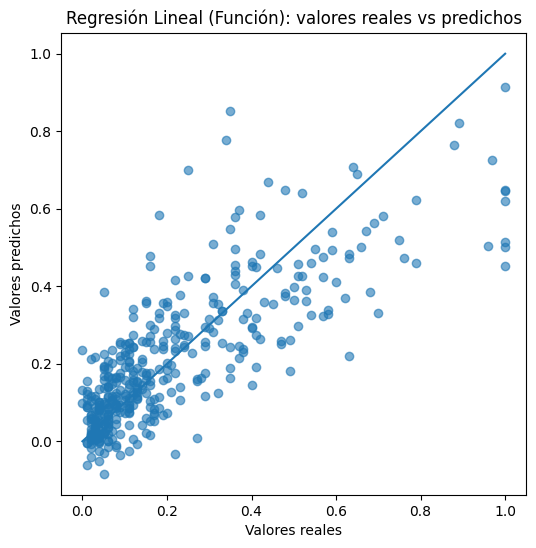

In [88]:
val_mae_lr, val_rmse_lr, val_r2_lr, test_mae_lr, test_rmse_lr, test_r2_lr, y_pred_lr = \
    evaluate_regression_model(
        linear_regression_pipeline,
        X_train, y_train, X_test, y_test,
        cv,
        scoring,
        model_name="Regresión Lineal"
    )

# Eliminar la entrada existente si el modelo ya está en la tabla
master_results_df = master_results_df[master_results_df['Modelo'] != "Regresión Lineal"].reset_index(drop=True)
# Añadir los resultados a la tabla maestra
master_results_df.loc[len(master_results_df)] = [
    "Regresión Lineal",
    val_mae_lr,
    val_rmse_lr,
    val_r2_lr,
    test_mae_lr,
    test_rmse_lr,
    test_r2_lr
]

print("\nTabla maestra de resultados actualizada:")
# Se muestra la tabla maestra con los resultados de Regresión Lineal
display(master_results_df)

# Opcional: Visualizar de nuevo los reales vs predichos para Regresión Lineal
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal (Función): valores reales vs predichos")
plt.show()

### Regresión Lineal con datos imputados


--- Evaluación del Modelo: Regresión Lineal Imputada ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std,IC_95
0,MAE,0.089227,0.096665,0.006379,0.004420
1,RMSE,0.125689,0.136752,0.009081,0.006293
2,R2,0.715964,0.658226,0.046909,0.032506



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.088409
1,RMSE,0.126226
2,R2,0.667338



Tabla maestra de resultados actualizada:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
0,Regresión Lineal,0.098442,0.138712,0.646758,0.094536,0.132840,0.631562
1,Regresión Lineal Imputada,0.096665,0.136752,0.658226,0.088409,0.126226,0.667338


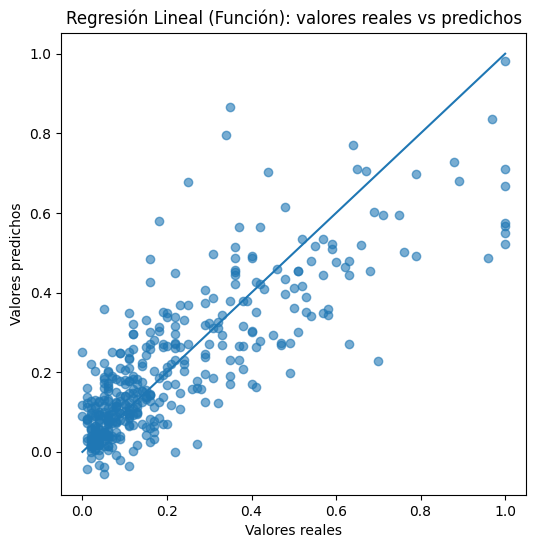

In [89]:
val_mae_lr, val_rmse_lr, val_r2_lr, test_mae_lr, test_rmse_lr, test_r2_lr, y_pred_lr = \
    evaluate_regression_model(
        linear_regression_pipeline,
        X_train_imputed, y_train_imputed, X_test_imputed, y_test_imputed,
        cv,
        scoring,
        model_name="Regresión Lineal Imputada"
    )

# Eliminar la entrada existente si el modelo ya está en la tabla
master_results_df = master_results_df[master_results_df['Modelo'] != "Regresión Lineal Imputada"].reset_index(drop=True)
# Añadir los resultados a la tabla maestra
master_results_df.loc[len(master_results_df)] = [
    "Regresión Lineal Imputada",
    val_mae_lr,
    val_rmse_lr,
    val_r2_lr,
    test_mae_lr,
    test_rmse_lr,
    test_r2_lr
]

print("\nTabla maestra de resultados actualizada:")
# Se muestra la tabla maestra con los resultados de Regresión Lineal
display(master_results_df)

# Opcional: Visualizar de nuevo los reales vs predichos para Regresión Lineal
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal (Función): valores reales vs predichos")
plt.show()

## RANDOM FOREST

Ahora implementaremos el modelo Random Forest Regressor, siguiendo la misma configuración experimental definida anteriormente para una comparación justa y rigurosa.

In [90]:
# Importar RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

# Construir el pipeline para Random Forest
random_forest_pipeline = Pipeline(steps=[
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

print("Pipeline de Random Forest creado con éxito.")

Pipeline de Random Forest creado con éxito.



--- Evaluación del Modelo: Random Forest ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std,IC_95
0,MAE,0.036030,0.096402,0.005152,0.003570
1,RMSE,0.052331,0.138534,0.007451,0.005164
2,R2,0.950757,0.648621,0.049034,0.033979



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.094081
1,RMSE,0.137363
2,R2,0.606049



Tabla maestra de resultados actualizada con Random Forest:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
0,Random Forest Regularized,0.093536,0.135120,0.665314,0.091229,0.133595,0.627367
1,Random Forest Optimized,0.094533,0.135938,0.662294,0.090980,0.132618,0.632795
2,Support Vector Regression (SVR),0.106233,0.143907,0.622249,0.106570,0.146876,0.549591
3,MLP Regressor (ANN),0.160094,0.211807,0.179359,0.164197,0.217425,0.012988
4,MLP Regressor Optimized,0.138476,0.185975,0.367140,0.130874,0.179572,0.326742
5,K-Neighbors Regressor,0.103009,0.150676,0.584839,0.098662,0.142571,0.575609
6,Regresión Lineal (PCA),0.098378,0.140119,0.640367,0.092084,0.131093,0.641194
7,Random Forest (PCA),0.109630,0.151303,0.583641,0.107161,0.143280,0.571381
8,Regresión Lineal,0.098443,0.138711,0.646760,0.094532,0.132837,0.631581
9,Random Forest,0.096402,0.138534,0.648621,0.094081,0.137363,0.606049


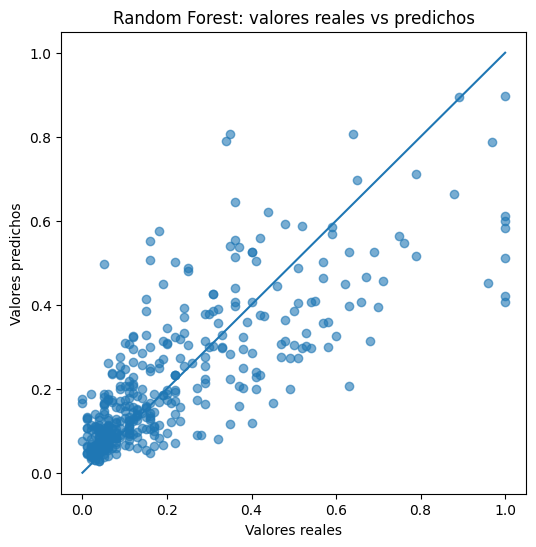

In [ ]:
# Usar la función general de evaluación para Random Forest
val_mae_rf, val_rmse_rf, val_r2_rf, test_mae_rf, test_rmse_rf, test_r2_rf, y_pred_rf = \
    evaluate_regression_model(
        random_forest_pipeline,
        X_train, y_train, X_test, y_test,
        cv,
        scoring,
        model_name="Random Forest"
    )

# Eliminar la entrada existente si el modelo ya está en la tabla
master_results_df = master_results_df[master_results_df['Modelo'] != "Random Forest"].reset_index(drop=True)
# Añadir los resultados a la tabla maestra
master_results_df.loc[len(master_results_df)] = [
    "Random Forest",
    val_mae_rf,
    val_rmse_rf,
    val_r2_rf,
    test_mae_rf,
    test_rmse_rf,
    test_r2_rf
]

print("\nTabla maestra de resultados actualizada con Random Forest:")
# Se muestra la tabla maestra con los resultados de Random Forest
display(master_results_df)

# Generar gráfica de valores reales vs predichos para Random Forest
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Random Forest: valores reales vs predichos")
plt.show()

### Interpretación de los Resultados de Random Forest

Al comparar el desempeño del modelo Random Forest con la Regresión Lineal, podemos observar si ha habido mejoras en las métricas de evaluación (MAE, RMSE, R²).

*   **Comparación con Regresión Lineal**: Generalmente, se espera que Random Forest, al ser un modelo de conjunto (ensemble) basado en árboles de decisión, capture relaciones no lineales y complejas en los datos, lo que a menudo resulta en un mejor rendimiento que un modelo lineal simple.
*   **R² y Errores**: Si el R² de Random Forest es significativamente más alto y los errores (MAE, RMSE) son más bajos que los de la Regresión Lineal, esto indica que el Random Forest es capaz de explicar una mayor proporción de la varianza en la variable objetivo y realiza predicciones más precisas. Una mejora en el R² y una reducción en los errores sugieren que las relaciones entre las características y la criminalidad violenta son probablemente no lineales.
*   **Posibles razones**: La capacidad de Random Forest para manejar interacciones entre características y su resistencia al sobreajuste (debido a la agregación de múltiples árboles) son factores clave que pueden contribuir a un mejor rendimiento, especialmente en datasets con relaciones complejas o ruidosas, como es común en datos sociales.